## Results

In [25]:
import json
from pathlib import Path

import pandas as pd
import pm4py
from river import metrics as river_metrics


ts_col = 'time:timestamp'
case_col = 'case:concept:name'
activity_col = 'concept:name'


DATASET_LIST = [
    'BPIC_12',
    'BPIC_12_A',
    'BPIC_12_O',
    'BPIC_12_W',
    'BPIC_13_C',
    'BPIC_13_I',
    'BPIC_15_1',
    'BPIC_15_2',
    'BPIC_15_3',
    'BPIC_15_4',
    'BPIC_15_5',
    'BPIC_20_DD',
    'BPIC_20_ID',
    'BPIC_20_PTC',
    'BPIC_20_RFP',
    'BPIC_20_TPD',
    'Helpdesk',
    'Hospital_Billing',
    'Sepsis',
    'Traffic_Fines',
]

DATASET_FOLDER = Path('C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/raw/')

In [ ]:
# Manual directory scanning
import os


scaned_dir = 'C:\\Users\\Pavel\\Desktop\\PROJECTS\\master-thesis\\experiments\\outputs\\streaming\\next_activity\\one_hot'
split_word = '_darwin'
final_dict = {}

for filename in os.listdir(scaned_dir):
    split_list = filename.split(split_word)
    dataset_name = split_list[0].upper()
    final_dict[dataset_name] = {'darwin': filename}

json_object = json.dumps(final_dict, indent=4)

# print(json_object)

In [23]:
BASE_FOLDER = Path(
    'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/experiments/outputs/streaming/'
)

BASE_FILENAME = 'results.csv'

PREDICTIONS_JSON_PATH = Path(
    'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/results/next_activity/results.json'
)

PREDICTIONS_DICT = json.load(PREDICTIONS_JSON_PATH.open())

START_EVENTS_JSON = Path(
    'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/results/next_activity/start_events.json'
)

START_EVENTS = json.load(START_EVENTS_JSON.open())

In [24]:
def get_predictions_path(task, comparison_name, dataset_name, model_name):
    predictions_folder = (
        PREDICTIONS_DICT.get(task, {})
        .get(comparison_name, {})
        .get(dataset_name, {})
        .get(model_name, None)
    )
    if predictions_folder is None:
        return None
    predictions_path = (
        BASE_FOLDER / task / comparison_name / predictions_folder / BASE_FILENAME
    )
    return predictions_path


def get_dataset_path(dataset_name):
    dataset_path = DATASET_FOLDER / f'{dataset_name}.xes'
    return dataset_path

## Predictions/stream comparison

In [16]:
def get_stream_df(dataset_path):
    original_stream_df = (
        pm4py.read_xes(str(dataset_path))
        .sort_values(by=[ts_col])
        .reset_index(drop=True)
    )
    original_stream_df[ts_col] = pd.to_datetime(original_stream_df[ts_col])

    return original_stream_df


def get_predictions_df(predictions_path):
    predictions_df = pd.read_csv(predictions_path)
    return predictions_df

In [184]:
task = 'next_activity'
task = 'remaining_time'
comparison_name = 'baseline'
model_name = 'darwin'
dataset_name = 'BPIC_20_DD'

dataset_path = get_dataset_path(dataset_name)
predictions_path = get_predictions_path(task, comparison_name, dataset_name, model_name)

stream_df = get_stream_df(dataset_path)

predictions_df = get_predictions_df(predictions_path)

len(stream_df), len(predictions_df)

parsing log, completed traces :: 100%|██████████| 10500/10500 [00:04<00:00, 2161.33it/s]


(56437, 56437)

In [86]:
task = 'next_activity'
comparison_name = 'baseline'
model_name = 'darwin_transformer'

for dataset_name in PREDICTIONS_DICT.get(task, {}).get(comparison_name, {}):
    dataset_path = get_dataset_path(dataset_name)
    predictions_path = get_predictions_path(
        task, comparison_name, dataset_name, model_name
    )
    if predictions_path is not None:
        stream_df = get_stream_df(dataset_path)
        predictions_df = get_predictions_df(predictions_path)
        print(
            f'{dataset_name}: {len(predictions_df)} predictions, {len(stream_df)} stream events'
        )

        event_names = stream_df['concept:name']
        event_times = stream_df['time:timestamp']

        predictions_df['event_name'] = event_names
        predictions_df['event_time'] = event_times

        columns_order = [
            'trace_id',
            'trace_n',
            'event_n',
            'event_name',
            'event_time',
            'y_true',
            'y_pred',
            'n_pred',
            'n_drifts',
            'drift_detected',
            'prefix_len',
            'loss',
            'accuracy',
            'macro_f1',
        ]

        predictions_df = predictions_df[columns_order]

        predictions_df.to_csv(
            predictions_path,
            index=False,
        )

parsing log, completed traces :: 100%|██████████| 1487/1487 [00:00<00:00, 4255.94it/s]


BPIC_13_C: 6660 predictions, 6660 stream events


parsing log, completed traces :: 100%|██████████| 7554/7554 [00:03<00:00, 2100.17it/s]


BPIC_13_I: 65533 predictions, 65533 stream events


parsing log, completed traces :: 100%|██████████| 10500/10500 [00:01<00:00, 6245.41it/s]


...

BPIC_20_RFP: 36796 predictions, 36796 stream events


parsing log, completed traces :: 100%|██████████| 7065/7065 [00:02<00:00, 2884.69it/s]


BPIC_20_TPD: 86581 predictions, 86581 stream events


parsing log, completed traces :: 100%|██████████| 4580/4580 [00:01<00:00, 2337.60it/s]


Helpdesk: 21348 predictions, 21348 stream events


## Performance plots (archive)

### F-score vs Prefix Length

How good is the model at predicting target when only a few events have been observed?

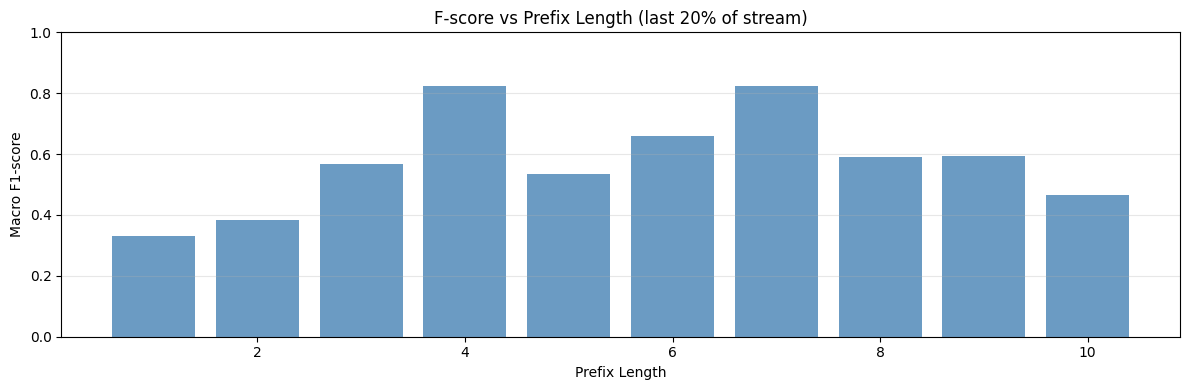

### F-score vs Stream Progress

Is the model performance changing over time? Display drift points

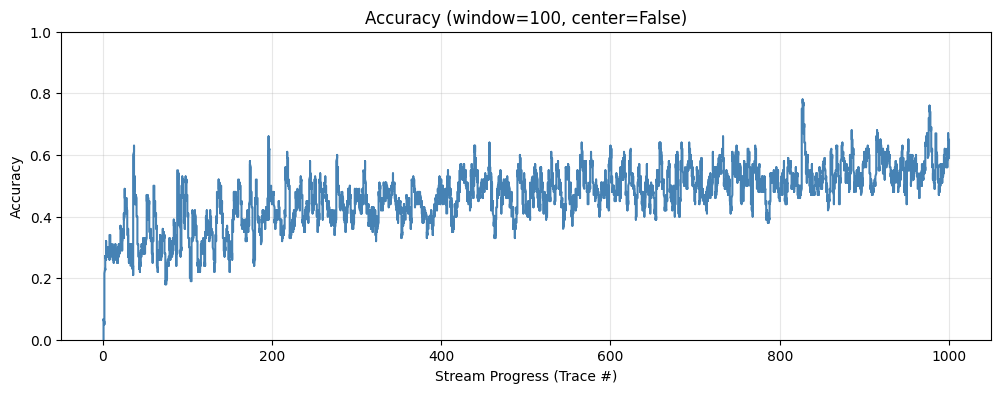

### Prediction Density

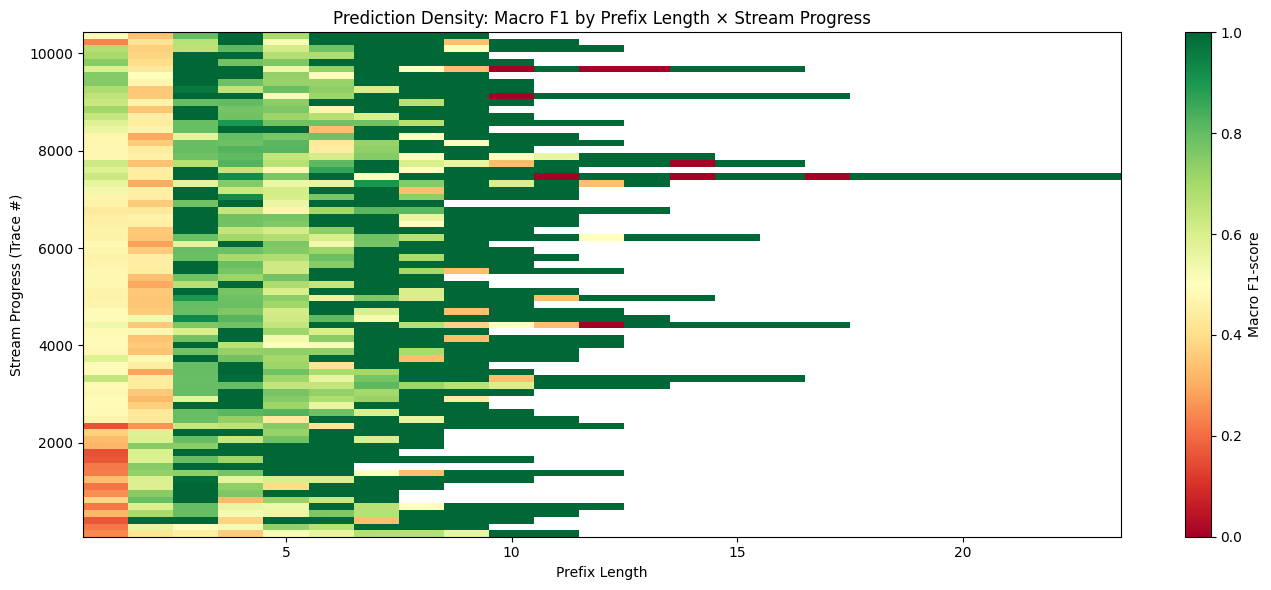

## Comparison table

In [ ]:
CLASSIFICATION_METRIC_FACTORIES = {
    'macro_f1': river_metrics.MacroF1,
    'accuracy': river_metrics.Accuracy,
}

REGRESSION_METRIC_FACTORIES = {
    'mae': river_metrics.MAE,
    'rmse': river_metrics.RMSE,
    'mape': river_metrics.MAPE,
}

In [19]:
def recompute_running_metrics(
    predictions_df: pd.DataFrame,
    metric_factories: dict,
    start_event_num: int = 0,
) -> pd.DataFrame:
    """Recompute running metrics from a given event onwards."""
    metrics_dict = {
        name: factory() for name, factory in metric_factories.items()
    }

    predictions_df = (
        predictions_df[predictions_df['event_n'] >= start_event_num]
        .sort_values('event_n')
        .reset_index(drop=True)
        .copy()
    )

    running_values = {name: [] for name in metrics_dict}

    for _, row in predictions_df.iterrows():
        y_true = row['y_true']
        y_pred = row['y_pred']

        if pd.notna(y_true) and pd.notna(y_pred):
            for metric in metrics_dict.values():
                metric.update(y_true, y_pred)

        for metric_name, metric in metrics_dict.items():
            running_values[metric_name].append(f'{metric.get():.3f}')

    for metric_name, values in running_values.items():
        predictions_df[metric_name] = values

    return predictions_df


def first_prediction_event_n(predictions_df: pd.DataFrame) -> float:
    """Return first event_n where model outputs a prediction."""
    pred_mask = pd.notna(predictions_df['y_pred'])

    if 'n_pred' in predictions_df.columns:
        pred_mask &= predictions_df['n_pred'] >= 1

    first_event = predictions_df.loc[pred_mask, 'event_n'].min()
    return first_event

### Next activity baseline

In [ ]:
NEXT_ACTIVITY_BASELINE_PATH = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/results/next_activity/baseline.csv'

task = 'next_activity'
comparison_name = 'baseline'
metric_factories = CLASSIFICATION_METRIC_FACTORIES
predictions_dict = PREDICTIONS_DICT.get(task, {}).get(comparison_name, {})

In [22]:
START_EVENTS = {}

for dataset_name, predictions_path_dict in predictions_dict.items():
    first_pred_events = {}
    for model_name, folder_path in predictions_path_dict.items():
        path = get_predictions_path(task, comparison_name, dataset_name, model_name)
        if path is None or not path.exists():
            continue
        df = pd.read_csv(path, low_memory=False)
        first_pred_events[model_name] = first_prediction_event_n(df)

    start_event_num = int(max(first_pred_events.values()))

    row = {'dataset_name': dataset_name}

    print(f'Dataset: {dataset_name}, start_event_num: {start_event_num}')

    START_EVENTS[dataset_name] = start_event_num

json.dump(START_EVENTS, open(str(START_EVENTS_JSON), 'w'), indent=4)

Dataset: BPIC_12, start_event_num: 26873
Dataset: BPIC_13_C, start_event_num: 960
Dataset: BPIC_13_I, start_event_num: 7210
Dataset: BPIC_15_1, start_event_num: 5420
Dataset: BPIC_18_C, start_event_num: 16131
Dataset: BPIC_18_G, start_event_num: 56922
Dataset: BPIC_18_P, start_event_num: 13351
Dataset: BPIC_20_DD, start_event_num: 7335
Dataset: BPIC_20_ID, start_event_num: 8389
Dataset: BPIC_20_PTC, start_event_num: 2112
Dataset: BPIC_20_RFP, start_event_num: 4762
Dataset: BPIC_20_TPD, start_event_num: 9831
Dataset: Helpdesk, start_event_num: 2704
Dataset: Sepsis, start_event_num: 1639
Dataset: Traffic_Fines, start_event_num: 82708


In [23]:
summary_rows = []

for dataset_name, predictions_path_dict in predictions_dict.items():
    start_event_num = START_EVENTS.get(dataset_name, None)

    print(f'Dataset: {dataset_name}, start_event_num: {start_event_num}')

    row = {'dataset_name': dataset_name}

    for model_name, folder_path in predictions_path_dict.items():
        path = get_predictions_path(task, comparison_name, dataset_name, model_name)
        if path is None or not path.exists() or start_event_num is None:
            continue
        df = pd.read_csv(path, low_memory=False)
        recomputed_df = recompute_running_metrics(
            df, start_event_num=start_event_num, metric_factories=metric_factories
        )

        last_row = recomputed_df.iloc[-1]

        for metric in metric_factories.keys():
            row[(metric, model_name)] = last_row[metric]

    summary_rows.append(row)

comparison_table_df = pd.DataFrame(summary_rows).set_index('dataset_name').sort_index()

Dataset: BPIC_12, start_event_num: 26873
Dataset: BPIC_13_C, start_event_num: 960
Dataset: BPIC_13_I, start_event_num: 7210
Dataset: BPIC_15_1, start_event_num: 5420
Dataset: BPIC_18_C, start_event_num: 16131
Dataset: BPIC_18_G, start_event_num: 56922
Dataset: BPIC_18_P, start_event_num: 13351
Dataset: BPIC_20_DD, start_event_num: 7335
Dataset: BPIC_20_ID, start_event_num: 8389
Dataset: BPIC_20_PTC, start_event_num: 2112
Dataset: BPIC_20_RFP, start_event_num: 4762
Dataset: BPIC_20_TPD, start_event_num: 9831
Dataset: Helpdesk, start_event_num: 2704
Dataset: Sepsis, start_event_num: 1639
Dataset: Traffic_Fines, start_event_num: 82708


In [24]:
comparison_table_df.to_csv(NEXT_ACTIVITY_BASELINE_PATH, index=True)

In [25]:
model_order = ['darwin', 'darwin_transformer', 'aht', 'arf', 'srp']
metric_order = ['macro_f1', 'accuracy']

if not comparison_table_df.empty:
    ordered_cols = [
        (metric, model_name)
        for metric in metric_order
        for model_name in model_order
        if (metric, model_name) in comparison_table_df.columns
    ]

    comparison_table_df = comparison_table_df[ordered_cols]
    comparison_table_df.columns = pd.MultiIndex.from_tuples(
        comparison_table_df.columns, names=['metric', 'model']
    )

comparison_table_df

metric        macro_f1                                         accuracy  \
model           darwin darwin_transformer    aht    arf    srp   darwin   
dataset_name                                                              
BPIC_12          0.606              0.587  0.608  0.584  0.542    0.836   
BPIC_13_C        0.418              0.314  0.401  0.454  0.454    0.514   
BPIC_13_I        0.432              0.350  0.270  0.326  0.318    0.645   
BPIC_15_1        0.183              0.116  0.206  0.247  0.250    0.395   
BPIC_18_C        0.475              0.473  0.460  0.416  0.397    0.830   
BPIC_18_G        0.332              0.346  0.353  0.429  0.401    0.663   
BPIC_18_P        0.412              0.423  0.347  0.308  0.287    0.694   
BPIC_20_DD       0.400              0.394  0.443  0.391  0.461    0.883   
BPIC_20_ID       0.433              0.432  0.396  0.417  0.414    0.831   
BPIC_20_PTC      0.358              0.354  0.451  0.495  0.462    0.775   
BPIC_20_RFP      0.400              0.381  0.384  0.370  0.407    0.860   
BPIC_20_TPD      0.366              0.357  0.350  0.262  0.240    0.739   
Helpdesk         0.241              0.220  0.231  0.289  0.279    0.793   
Sepsis           0.424              0.292  0.375  0.385  0.358    0.582   
Traffic_Fines    0.575              0.530  0.584  0.376  0.367    0.575   

metric                                                 
model         darwin_transformer    aht    arf    srp  
dataset_name                                           
BPIC_12                    0.817  0.826  0.831  0.800  
BPIC_13_C                  0.483  0.565  0.622  0.613  
BPIC_13_I                  0.616  0.634  0.637  0.640  
BPIC_15_1                  0.279  0.388  0.446  0.447  
BPIC_18_C                  0.829  0.809  0.727  0.695  
BPIC_18_G                  0.718  0.749  0.816  0.781  
BPIC_18_P                  0.713  0.636  0.608  0.603  
BPIC_20_DD                 0.883  0.865  0.890  0.886  
BPIC_20_ID                 0.834  0.793  0.823  0.814  
BPIC_20_PTC                0.770  0.818  0.848  0.831  
BPIC_20_RFP                0.877  0.870  0.877  0.867  
BPIC_20_TPD                0.732  0.769  0.625  0.606  
Helpdesk                   0.793  0.765  0.822  0.821  
Sepsis                     0.467  0.573  0.601  0.573  
Traffic_Fines              0.559  0.759  0.430  0.416

### Remaining time baseline

In [10]:
task = 'remaining_time'
comparison_name = 'baseline'
predictions_dict = PREDICTIONS_DICT.get(task, {}).get(comparison_name, {})
metric_factories = REGRESSION_METRIC_FACTORIES

In [ ]:
model_name = 'darwin_transformer'
dataset_name = 'Traffic_Fines'

path = get_predictions_path(task, comparison_name, dataset_name, model_name)

predictions_df = pd.read_csv(path)

pred_mask = pd.notna(predictions_df['y_pred'])

pred_mask &= predictions_df['n_pred'] >= 1

predictions_df.loc[pred_mask]

# predictions_df[(predictions_df.index < 1948) & (predictions_df.index > 1930)]

# first_event = predictions_df.loc[pred_mask, 'event_n'].min()

predictions_df.tail()

,trace_id,trace_n,event_n,event_name,event_time,y_true,y_pred,error,n_pred,n_drifts,drift_detected,prefix_len,loss,mae,rmse


In [24]:
recomputed_df = recompute_running_metrics(
    predictions_df, start_event_num=0, metric_factories=metric_factories
)

In [25]:
recomputed_df.tail()

,trace_id,trace_n,event_n,event_name,event_time,y_true,y_pred,error,n_pred,n_drifts,drift_detected,prefix_len,loss,mae,rmse,mape
561465,S194275,150350,561466,Payment,2013-06-18 00:00:00+00:00,NaN,NaN,NaN,319821,912,False,2,461.419235,284.747,354.531,1344.620
561466,S193829,150358,561467,Payment,2013-06-18 00:00:00+00:00,NaN,NaN,NaN,319822,912,False,2,461.419235,284.747,354.531,1344.620
561467,S192460,150346,561468,Payment,2013-06-18 00:00:00+00:00,NaN,NaN,NaN,319823,912,False,2,461.419235,284.747,354.531,1344.620
561468,S192520,150370,561469,Payment,2013-06-18 00:00:00+00:00,NaN,NaN,NaN,319824,912,False,2,461.419235,284.747,354.531,1344.620
561469,S194560,150351,561470,Payment,2013-06-18 00:00:00+00:00,NaN,NaN,NaN,319825,912,False,2,461.419235,284.747,354.531,1344.620


In [11]:
summary_rows = []

for dataset_name, predictions_path_dict in predictions_dict.items():
    row = {'dataset_name': dataset_name}

    for model_name, folder_path in predictions_path_dict.items():
        path = get_predictions_path(task, comparison_name, dataset_name, model_name)
        df = pd.read_csv(path)
        recomputed_df = recompute_running_metrics(
            df, start_event_num=0, metric_factories=metric_factories
        )

        last_row = recomputed_df.iloc[-1]

        for metric in metric_factories.keys():
            row[(metric, model_name)] = last_row[metric]

    summary_rows.append(row)

comparison_table_df = pd.DataFrame(summary_rows).set_index('dataset_name').sort_index()

In [12]:
model_order = ['darwin', 'darwin_transformer']
metric_order = ['mae', 'rmse', 'mape']

if not comparison_table_df.empty:
    ordered_cols = [
        (metric, model_name)
        for metric in metric_order
        for model_name in model_order
        if (metric, model_name) in comparison_table_df.columns
    ]

    comparison_table_df = comparison_table_df[ordered_cols]
    comparison_table_df.columns = pd.MultiIndex.from_tuples(
        comparison_table_df.columns, names=['metric', 'model']
    )

comparison_table_df

metric                mae                        rmse                     \
model              darwin darwin_transformer   darwin darwin_transformer   
dataset_name                                                               
BPIC_20_DD          4.985              5.488   11.227             12.149   
BPIC_20_ID         27.821              5.488   47.021             12.149   
BPIC_20_PTC        16.566             15.426   31.716             32.592   
BPIC_20_RFP         6.132              5.659   13.447             13.361   
BPIC_20_TPD        33.340             36.886   51.562             57.660   
Helpdesk            8.599              9.304   10.834             11.470   
Hospital_Billing   70.716             74.172  117.233            122.757   
Traffic_Fines     284.747            336.036  354.531            448.939   

metric                  mape                     
model                 darwin darwin_transformer  
dataset_name                                     
BPIC_20_DD           386.042            508.053  
BPIC_20_ID           253.557            508.053  
BPIC_20_PTC        48547.333          42358.476  
BPIC_20_RFP         1962.463           1929.108  
BPIC_20_TPD        92006.848          75139.427  
Helpdesk            1988.342           2433.445  
Hospital_Billing  667893.293        1112395.391  
Traffic_Fines       1344.620            409.311

### Encoding Comparison: One-hot vs Word2Vec

In [45]:
NEXT_ACTIVITY_BASELINE_PATH = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/results/next_activity/baseline.csv'

ENCODING_COMPARISON_PATH = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/results/next_activity/encoding_comparison.csv'

task = 'next_activity'
model_name = 'darwin'
metric_factories = CLASSIFICATION_METRIC_FACTORIES

word2vec_predictions_path = PREDICTIONS_DICT.get(task, {}).get('baseline', {})

one_hot_predictions_path = PREDICTIONS_DICT.get(task, {}).get('one_hot', {})

In [48]:
summary_rows = []

for dataset_name, word2vec_dict in word2vec_predictions_path.items():
    one_hot_dict = one_hot_predictions_path.get(dataset_name, {})

    word2vec_path = get_predictions_path(task, 'baseline', dataset_name, model_name)
    one_hot_path = get_predictions_path(task, 'one_hot', dataset_name, model_name)

    # print(f'Dataset: {dataset_name}')
    # print(f'Word2Vec path: {word2vec_path}')
    # print(f'One-hot path: {one_hot_path}')

    start_event_num = START_EVENTS.get(dataset_name, None)

    if word2vec_path is None or not word2vec_path.exists():
        print(f'skip {dataset_name} 1')
        print(word2vec_path)
        continue
    if one_hot_path is None or not one_hot_path.exists():
        print(f'skip {dataset_name} 2')
        continue
    if start_event_num is None:
        print(f'skip {dataset_name} 3')
        continue

    word2vec_df = pd.read_csv(word2vec_path, low_memory=False)
    one_hot_df = pd.read_csv(one_hot_path, low_memory=False)

    recomputed_word2vec_df = recompute_running_metrics(
        word2vec_df, start_event_num=start_event_num, metric_factories=metric_factories
    )

    recomputed_one_hot_df = recompute_running_metrics(
        one_hot_df, start_event_num=start_event_num, metric_factories=metric_factories
    )

    word2vec_last_row = recomputed_word2vec_df.iloc[-1]
    one_hot_last_row = recomputed_one_hot_df.iloc[-1]

    row = {'dataset_name': dataset_name}

    for metric in metric_factories.keys():
        row[(metric, 'word2vec')] = word2vec_last_row[metric]
        row[(metric, 'one_hot')] = one_hot_last_row[metric]

    summary_rows.append(row)

comparison_table_df = pd.DataFrame(summary_rows).set_index('dataset_name').sort_index()

In [49]:
comparison_table_df.to_csv(ENCODING_COMPARISON_PATH, index=True)

In [50]:
encoding_order = ['one_hot', 'word2vec']
metric_order = ['macro_f1', 'accuracy']

if not comparison_table_df.empty:
    ordered_cols = [
        (metric, encoding)
        for metric in metric_order
        for encoding in encoding_order
        if (metric, encoding) in comparison_table_df.columns
    ]

    comparison_table_df = comparison_table_df[ordered_cols]
    comparison_table_df.columns = pd.MultiIndex.from_tuples(
        comparison_table_df.columns, names=['metric', 'encoding']
    )

comparison_table_df

metric        macro_f1          accuracy         
encoding       one_hot word2vec  one_hot word2vec
dataset_name                                     
BPIC_12          0.610    0.606    0.836    0.836
BPIC_13_C        0.318    0.418    0.485    0.514
BPIC_13_I        0.419    0.432    0.666    0.645
BPIC_15_1        0.168    0.183    0.361    0.395
BPIC_18_C        0.434    0.475    0.747    0.830
BPIC_18_G        0.381    0.332    0.764    0.663
BPIC_18_P        0.418    0.412    0.712    0.694
BPIC_20_DD       0.395    0.400    0.882    0.883
BPIC_20_ID       0.422    0.433    0.815    0.831
BPIC_20_PTC      0.397    0.358    0.780    0.775
BPIC_20_RFP      0.376    0.400    0.865    0.860
BPIC_20_TPD      0.367    0.366    0.756    0.739
Helpdesk         0.262    0.241    0.810    0.793
Sepsis           0.428    0.424    0.588    0.582
Traffic_Fines    0.563    0.575    0.570    0.575

## Performance plots

### Shared functions

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
)

In [10]:
def get_bins(
    predictions_df,
    n_bins=10,
    case_id_filter=None,
    case_col='trace_id',
    ts_col='event_time',
    y_true_col='y_true',
    y_pred_col='y_pred',
):
    df = predictions_df.copy()
    df[ts_col] = pd.to_datetime(df[ts_col])

    df = df.dropna(subset=[y_true_col, y_pred_col])

    if case_id_filter is not None:
        df = df[df[case_col] == case_id_filter]

    if df.empty:
        return [[] for _ in range(n_bins)], [[] for _ in range(n_bins)]

    df = df.sort_values(by=[case_col, ts_col])
    grouped = df.groupby(case_col)

    t_min = grouped[ts_col].transform('min')
    t_max = grouped[ts_col].transform('max')
    duration = (t_max - t_min).dt.total_seconds()
    current_offset = (df[ts_col] - t_min).dt.total_seconds()

    event_n = grouped.cumcount()
    total_events = grouped[ts_col].transform('count')

    df['time_prog'] = np.where(duration > 0, current_offset / duration, 0.0)
    df['event_prog'] = np.where(total_events > 1, event_n / (total_events - 1), 0.0)

    bins_edges = np.linspace(0, 1, n_bins + 1)
    labels = range(n_bins)

    df['time_bin_idx'] = pd.cut(
        df['time_prog'], bins=bins_edges, labels=labels, include_lowest=True
    ).astype(int)
    df['event_bin_idx'] = pd.cut(
        df['event_prog'], bins=bins_edges, labels=labels, include_lowest=True
    ).astype(int)

    time_bins = [[] for _ in range(n_bins)]
    event_bins = [[] for _ in range(n_bins)]

    for b_idx, group in df.groupby('time_bin_idx'):
        data = list(
            zip(group[case_col], group[y_pred_col], group[y_true_col], strict=True)
        )
        time_bins[int(b_idx)] = data

    for b_idx, group in df.groupby('event_bin_idx'):
        data = list(
            zip(group[case_col], group[y_pred_col], group[y_true_col], strict=True)
        )
        event_bins[int(b_idx)] = data

    return time_bins, event_bins

### Next activity

In [11]:
def get_bin_metrics(
    predictions_df,
    metrics,
    n_bins=10,
    case_id_filter=None,
    case_col='trace_id',
    ts_col='event_time',
):
    time_bins, event_bins = get_bins(
        predictions_df=predictions_df,
        n_bins=n_bins,
        case_id_filter=case_id_filter,
        case_col=case_col,
        ts_col=ts_col,
    )

    def compute_metrics(bins):
        results = {m: [np.nan] * n_bins for m in metrics}
        for i, b in enumerate(bins):
            if not b:
                continue
            _, y_preds, y_trues = zip(*b, strict=True)
            y_preds = list(y_preds)
            y_trues = list(y_trues)
            for m_name, m_func in metrics.items():
                results[m_name][i] = float(m_func(y_trues, y_preds))
        return results

    def compute_counts(bins):
        return [len(b) for b in bins]

    time_metrics = compute_metrics(time_bins)
    event_metrics = compute_metrics(event_bins)

    time_counts = compute_counts(time_bins)
    event_counts = compute_counts(event_bins)

    return time_metrics, event_metrics, time_counts, event_counts

In [19]:
metrics = {
    'macro_f1': lambda y_true, y_pred: f1_score(y_true, y_pred, average='macro'),
    'accuracy': accuracy_score,
}

task = 'next_activity'
comparison_name = 'baseline'
# dataset_name = 'BPIC_20_TPD'
dataset_name = 'BPIC_20_DD'
dataset_name = 'Helpdesk'
# model_name = 'darwin_transformer'
model_name = 'darwin'

predictions_path = get_predictions_path(task, comparison_name, dataset_name, model_name)
dataset_path = get_dataset_path(dataset_name)

predictions_df = get_predictions_df(predictions_path)

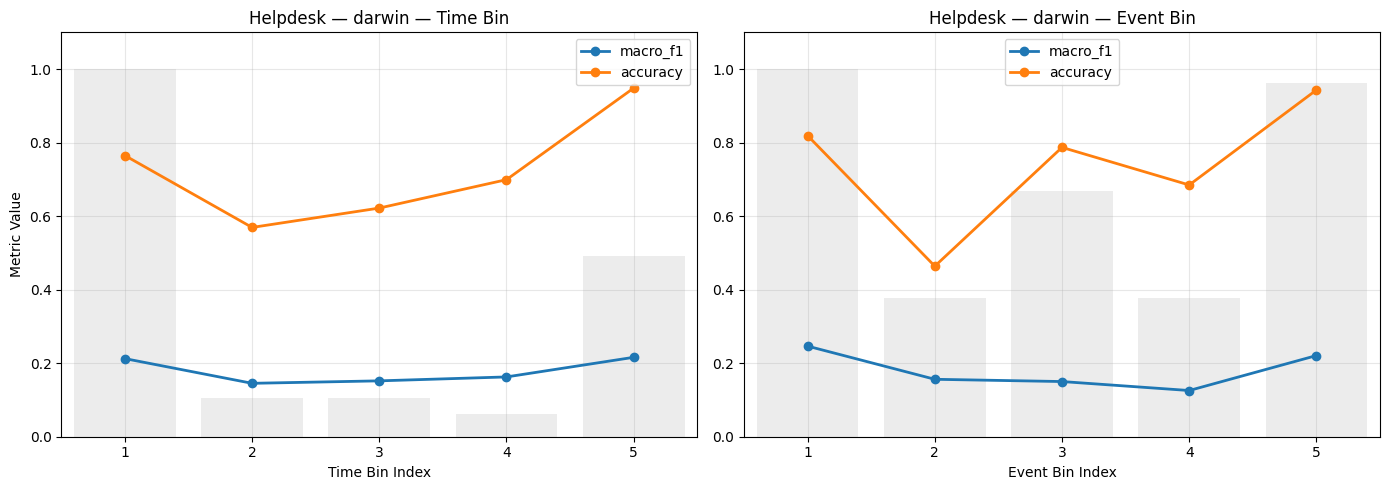

In [20]:
n_bins = 5

time_metrics, event_metrics, time_counts, event_counts = get_bin_metrics(
    predictions_df=predictions_df,
    metrics=metrics,
    n_bins=n_bins,
    # case_id_filter='travel permit 65106', # 3 events (2 preds)
    # case_id_filter='travel permit 83467', # 10 events (5 init events, 5 preds)
    # case_id_filter='travel permit 10482', # 10 events (9 preds)
    # case_id_filter='travel permit 13587', # 11 events (10 preds)
    # case_id_filter='travel permit 15078', # 14 events (13 preds)
)

max_time_count = max(time_counts) if max(time_counts) > 0 else 1
max_event_count = max(event_counts) if max(event_counts) > 0 else 1
time_counts_norm = [c / max_time_count for c in time_counts]
event_counts_norm = [c / max_event_count for c in event_counts]

x = range(1, n_bins + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time metrics
for m_name, vals in time_metrics.items():
    axes[0].plot(x, vals, marker='o', linewidth=2, label=m_name)
axes[0].bar(x, time_counts_norm, color='gray', alpha=0.15, width=0.8, zorder=0)
axes[0].set_xlabel('Time Bin Index')
axes[0].set_ylabel('Metric Value')
axes[0].set_title(f'{dataset_name} — {model_name} — Time Bin')
axes[0].set_xticks(list(x))
axes[0].set_xlim(0.5, n_bins + 0.5)
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].grid(True, alpha=0.3, zorder=1)

# Event metrics
for m_name, vals in event_metrics.items():
    axes[1].plot(x, vals, marker='o', linewidth=2, label=m_name)
axes[1].bar(x, event_counts_norm, color='gray', alpha=0.15, width=0.8, zorder=0)
axes[1].set_xlabel('Event Bin Index')
axes[1].set_title(f'{dataset_name} — {model_name} — Event Bin')
axes[1].set_xticks(list(x))
axes[1].set_xlim(0.5, n_bins + 0.5)
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].grid(True, alpha=0.3, zorder=1)

plt.tight_layout()
plt.show()

In [182]:
_model_names = [
    'darwin',
    'darwin_transformer',
]

metric = 'macro_f1'
n_bins = 10

time_metrics_dict = {}
event_metrics_dict = {}

for _model_name in _model_names:
    _time_metrics_dict = {}
    _event_metrics_dict = {}

    for _dataset_name in DATASET_LIST:
        predictions_path = get_predictions_path(
            task, comparison_name, _dataset_name, _model_name
        )
        if predictions_path is None:
            continue

        _predictions_df = get_predictions_df(predictions_path)

        _time_metrics, _event_metrics, _time_counts, _event_counts = get_bin_metrics(
            predictions_df=_predictions_df,
            metrics=metrics,
            n_bins=n_bins,
        )

        _time_metrics_dict[_dataset_name] = _time_metrics[metric]
        _event_metrics_dict[_dataset_name] = _event_metrics[metric]

    time_metrics_dict[_model_name] = _time_metrics_dict
    event_metrics_dict[_model_name] = _event_metrics_dict

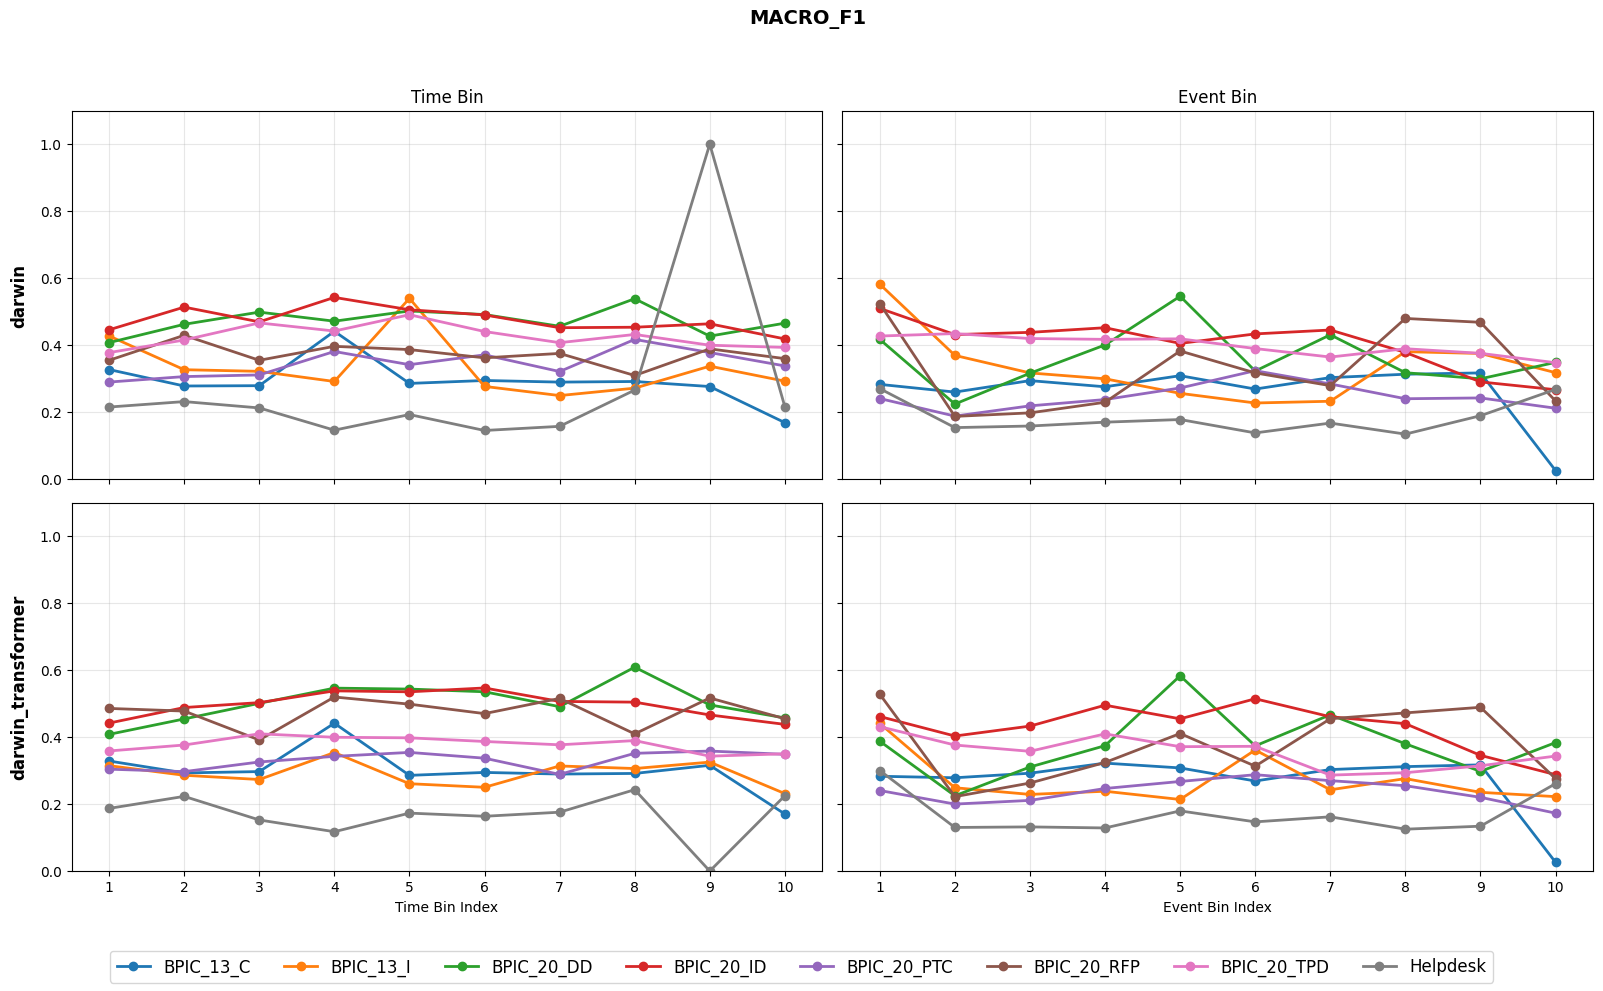

In [183]:
x = range(1, n_bins + 1)
n_models = len(_model_names)

fig, axes = plt.subplots(
    nrows=n_models,
    ncols=2,
    figsize=(16, 5 * n_models),
    squeeze=False,
    sharex=True,
    sharey=True,
)

for row_idx, model_name in enumerate(_model_names):
    model_time = time_metrics_dict.get(model_name, {})
    model_event = event_metrics_dict.get(model_name, {})

    ax_time = axes[row_idx, 0]
    ax_event = axes[row_idx, 1]

    for dataset_name, vals in model_time.items():
        ax_time.plot(x, vals, marker='o', linewidth=2, label=dataset_name)
    for dataset_name, vals in model_event.items():
        ax_event.plot(x, vals, marker='o', linewidth=2, label=dataset_name)

    # common axis styling
    for ax in (ax_time, ax_event):
        ax.set_xticks(list(x))
        ax.set_xlim(0.5, n_bins + 0.5)
        ax.set_ylim(0, 1.1)
        ax.grid(True, alpha=0.3)

    if row_idx == len(_model_names) - 1:
        ax_time.set_xlabel('Time Bin Index')
        ax_event.set_xlabel('Event Bin Index')

    # annotate model name
    ax_time.text(
        -0.07,
        0.5,
        model_name,
        transform=ax_time.transAxes,
        va='center',
        ha='center',
        rotation=90,
        fontsize=12,
        fontweight='bold',
    )

# set column titles
axes[0, 0].set_title('Time Bin')
axes[0, 1].set_title('Event Bin')

# overall metric as figure title
fig.suptitle(metric.upper(), fontsize=14, fontweight='bold',)

all_handles, all_labels = [], []
for ax in axes.flatten():
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l, strict=True):
        if ll not in all_labels:
            all_handles.append(hh)
            all_labels.append(ll)

ncols = min(len(all_labels), 10) if all_labels else 1
fig.legend(
    all_handles,
    all_labels,
    loc='lower center',
    ncol=ncols,
    fontsize=12,
    frameon=True,
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

### Remaining time

In [30]:
def get_bin_metrics(
    predictions_df,
    metrics,
    n_bins=10,
    case_id_filter=None,
    case_col='trace_id',
    ts_col='event_time',
):
    time_bins, event_bins = get_bins(
        predictions_df=predictions_df,
        n_bins=n_bins,
        case_id_filter=case_id_filter,
        case_col=case_col,
        ts_col=ts_col,
    )

    def compute_metrics(bins):
        results = {m: [np.nan] * n_bins for m in metrics}
        for i, b in enumerate(bins):
            if not b:
                continue
            _, y_preds, y_trues = zip(*b, strict=True)
            y_preds = list(y_preds)
            y_trues = list(y_trues)
            for m_name, m_func in metrics.items():
                results[m_name][i] = float(m_func(y_trues, y_preds))
        return results

    def compute_counts(bins):
        return [len(b) for b in bins]

    def compute_box_values(bins):
        values = []
        for bin_rows in bins:
            if not bin_rows:
                values.append([])
                continue
            _, y_preds, y_trues = zip(*bin_rows, strict=True)
            bin_errors = [
                abs(float(y_t) - float(y_p))
                for y_t, y_p in zip(y_trues, y_preds, strict=True)
            ]
            values.append(bin_errors)
        return values

    time_box_values = compute_box_values(time_bins)
    event_box_values = compute_box_values(event_bins)

    time_metrics = compute_metrics(time_bins)
    event_metrics = compute_metrics(event_bins)

    time_counts = compute_counts(time_bins)
    event_counts = compute_counts(event_bins)

    return (
        time_metrics,
        event_metrics,
        time_counts,
        event_counts,
        time_box_values,
        event_box_values,
    )

In [34]:
metrics = {
    # 'rmse': root_mean_squared_error,
    'mae': mean_absolute_error,
    # 'mape': mean_absolute_percentage_error,
}

task = 'remaining_time'
comparison_name = 'baseline'
dataset_name = 'Helpdesk'
dataset_name = 'BPIC_20_DD'
model_name = 'darwin'

predictions_path = get_predictions_path(task, comparison_name, dataset_name, model_name)

predictions_df = get_predictions_df(predictions_path)

In [35]:
n_bins = 5

(
    time_metrics,
    event_metrics,
    time_counts,
    event_counts,
    time_box_values,
    event_box_values,
) = get_bin_metrics(predictions_df=predictions_df, metrics=metrics, n_bins=n_bins)

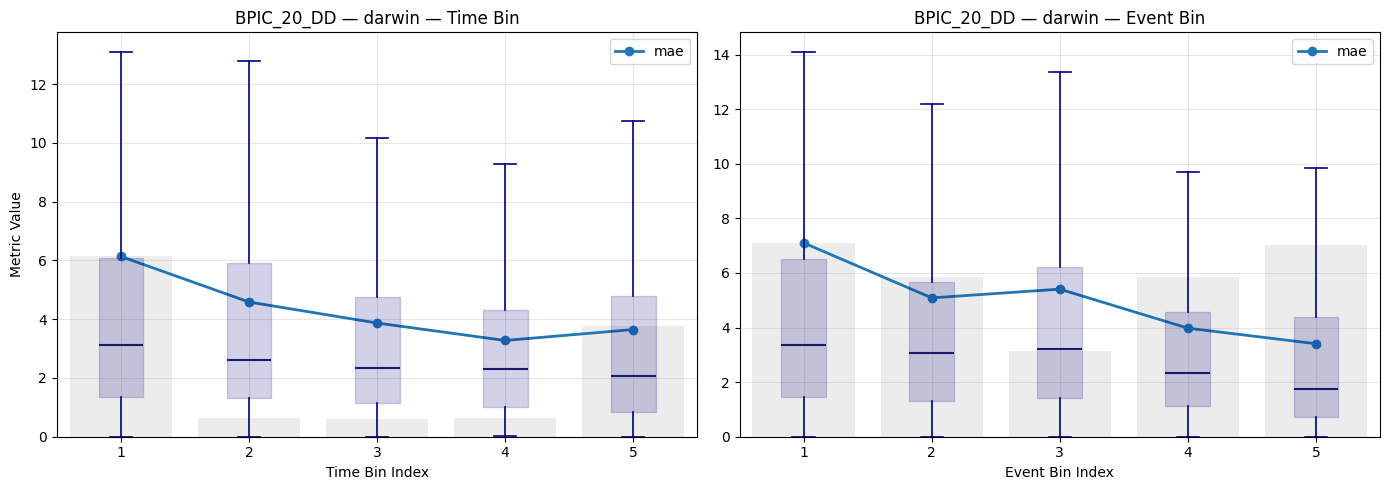

In [36]:
max_time_count = max(max(time_counts), 1)
max_event_count = max(max(event_counts), 1)

max_time_metric = max(
    [np.nanmax(vals) for vals in time_metrics.values() if len(vals) > 0] + [1.0]
)
max_event_metric = max(
    [np.nanmax(vals) for vals in event_metrics.values() if len(vals) > 0] + [1.0]
)

time_counts_norm = [c / max_time_count * max_time_metric for c in time_counts]
event_counts_norm = [c / max_event_count * max_event_metric for c in event_counts]

x = range(1, n_bins + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

box_plot_props = {
    'positions': list(x),
    'widths': 0.35,
    'whis': 1.5,
    'showfliers': False,
    'patch_artist': True,
    'boxprops': {'facecolor': 'navy', 'alpha': 0.18, 'color': 'navy'},
    'whiskerprops': {'color': 'navy', 'linewidth': 1.2},
    'capprops': {'color': 'navy', 'linewidth': 1.2},
    'medianprops': {'color': 'midnightblue', 'linewidth': 1.5},
    'zorder': 3,
}

# Time metrics
for m_name, vals in time_metrics.items():
    axes[0].plot(x, vals, marker='o', linewidth=2, label=m_name)

axes[0].bar(x, time_counts_norm, color='gray', alpha=0.15, width=0.8, zorder=0)
axes[0].boxplot(time_box_values, **box_plot_props)
axes[0].set_xlabel('Time Bin Index')
axes[0].set_ylabel('Metric Value')
axes[0].set_title(f'{dataset_name} — {model_name} — Time Bin')
axes[0].set_xticks(list(x))
axes[0].set_xlim(0.5, n_bins + 0.5)
axes[0].legend()
axes[0].grid(True, alpha=0.3, zorder=1)

# Event metrics
for m_name, vals in event_metrics.items():
    axes[1].plot(x, vals, marker='o', linewidth=2, label=m_name)

axes[1].bar(x, event_counts_norm, color='gray', alpha=0.15, width=0.8, zorder=0)
axes[1].boxplot(event_box_values, **box_plot_props)
axes[1].set_xlabel('Event Bin Index')
axes[1].set_title(f'{dataset_name} — {model_name} — Event Bin')
axes[1].set_xticks(list(x))
axes[1].set_xlim(0.5, n_bins + 0.5)
axes[1].legend()
axes[1].grid(True, alpha=0.3, zorder=1)

plt.tight_layout()
plt.show()